# In silico test platform for cardiac electrophysiology

Running computer simulations of cardiac activation has few names: 
- Cardiac digital twin
- Computational cardiology
- Computer modelling of the heart

# Install finitewave

In [ ]:
%pip install finitewave

# Virtual heart, experiment 1: singe-cell action potential

The Courtemanche-Ramirez-Nattel human atrial model [1].

1. Courtemanche, Marc, Rafael J. Ramirez, and Stanley Nattel. "Ionic mechanisms underlying human atrial action potential properties: insights from a mathematical model." American Journal of Physiology-Heart and Circulatory Physiology 275.1 (1998): H301-H321.

### 1a: standard atrial action potential

In [1]:
# Let's create a 3x3 tissue with one cardiomyocyte in the center and stimulate it. The action potential of the cell is tracked and plotted.

import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw

# create model object and set up parameters:
cardiac_model = fw.Courtemanche() # use the update rule invented by Courtemanche et al. (1998) to update the state of each cell in the tissue.
cardiac_model.dt = 0.01     # (ms).   each update, predict 0.01 ms into the future
cardiac_model.dr = 0.25     # (mm).   each grid cell is 0.25 mm in size
cardiac_model.t_max = 600   # (ms).   compute the tissue for 600 ms, i.e. one heart beat.

# tell how big the tissue is 
n, m = 3, 3
tissue = fw.CardiacTissue([n, m])
cardiac_model.cardiac_tissue = tissue

# tell the simulation which results to keep in memory. In this case, we want to track the action potential of the cell at coordinates (1,1).
act_pot_tracker = fw.ActionPotentialTracker()
act_pot_tracker.cell_ind = [1, 1] # coordinates of tracked cell. Cells are numbered 0,1,2 in horizontal and vertical directions. 
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(act_pot_tracker)
cardiac_model.tracker_sequence = tracker_sequence

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=100,      # ms
                                           curr_value=20, # pA
                                           duration=2,    # ms
                                           x1=1, x2=2,   # coordinates of the stimulated cell. All coords>=x1 and <x2 will be stimulated. In this case, only the cell at (1,1) is stimulated.
                                           y1=1, y2=2)) # same for y-coordinates
cardiac_model.stim_sequence = stim_sequence

# we are all set! let's simulate one action potential 
cardiac_model.run()

Running Courtemanche: 100%|██████████| 60000/60000 [00:13<00:00, 4405.45it/s]


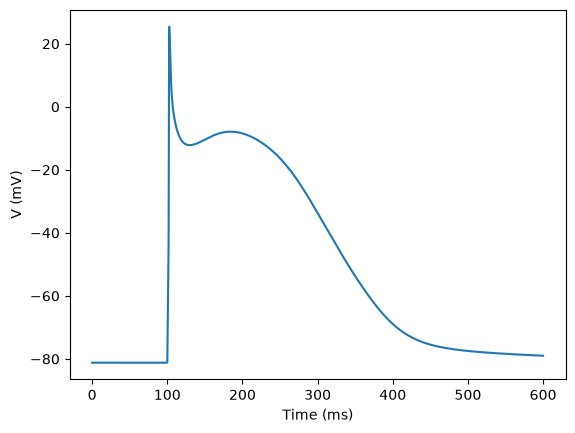

In [2]:
# look at the result (standard python code) 

times = np.arange(0, cardiac_model.t_max, cardiac_model.dt)
# show the potential map at the end of calculations:
plt.figure()
plt.plot(times, act_pot_tracker.output)
plt.ylabel("V (mV)")
plt.xlabel("Time (ms)")
plt.show()

### 1b. The effects of remodelling

Electrophysiological remodelling [2].

2. Roney, Caroline H., et al. "Modelling methodology of atrial fibrosis affects rotor dynamics and electrograms." EP Europace 18.suppl_4 (2016): iv146-iv155.

In [ ]:

# copy the code from the normal cell and change the parameters to simulate a remodeled cell.  
n, m = 3, 3
dt = 0.01
dr = 0.25
t_max = 600

# create a tissue with one cardiomycyte:
tissue = fw.CardiacTissue([n, m])

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimCurrentCoord(time=100,      # ms
                                           curr_value=20, # pA
                                           duration=2,    # ms
                                           x1=1, x2=2,
                                           y1=1, y2=2))

act_pot_tracker_remodeling = fw.ActionPotentialTracker()
act_pot_tracker_remodeling.cell_ind = [1, 1]

tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(act_pot_tracker_remodeling)

# create model object for the modified cell and set up parameters:
cardiac_model_remodeled = fw.Courtemanche()
cardiac_model_remodeled.gk1 *= 2
cardiac_model_remodeled.gks *= 2
cardiac_model_remodeled.gkr *= 1.6
cardiac_model_remodeled.gcal *= 0.45
cardiac_model_remodeled.gto *= 0.35
cardiac_model_remodeled.ipcamax *= 1.5
cardiac_model_remodeled.inacamax *= 1.6
cardiac_model_remodeled.dt = dt
cardiac_model_remodeled.dr = dr
cardiac_model_remodeled.t_max = t_max
# add the tissue and the stim parameters to the model object:
cardiac_model_remodeled.cardiac_tissue = tissue
cardiac_model_remodeled.stim_sequence = stim_sequence
cardiac_model_remodeled.tracker_sequence = tracker_sequence

# run the model:
cardiac_model_remodeled.run()



AttributeError: 'Courtemanche' object has no attribute 'gkur_coeff'

What do you expect with these changes? 
* increased K conductance
* reduced Ca current 

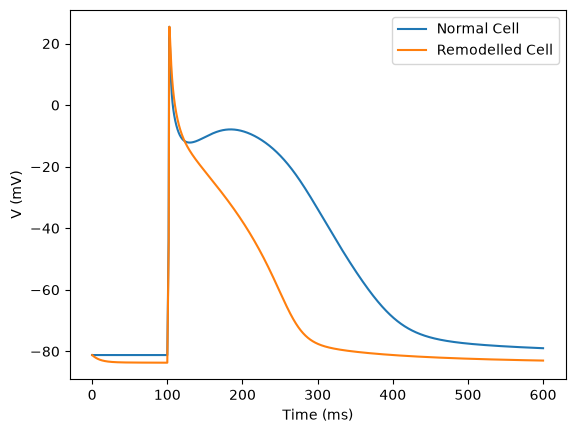

In [4]:
times = np.arange(0, t_max, dt)
# show the potential map at the end of calculations:
plt.figure()
plt.plot(times, act_pot_tracker.output, label="Normal Cell")
plt.plot(times, act_pot_tracker_remodeling.output, label="Remodelled Cell")
plt.ylabel("V (mV)")
plt.xlabel("Time (ms)")
plt.legend()
plt.show()

# Virtual heart, experiment 2: a tissue sheet

### 2a. Cardiac activation wave in a disc-shaped domain (simplified atrium / in vitro culture)

In [ ]:
n = 256 # 64 (mm)

# create a circular mesh to represent the tissue. The cells outside the circle are not part of the tissue and will be ignored in the simulation.
x, y = np.meshgrid(np.arange(n), np.arange(n))
X, Y = x.flatten(), y.flatten()
R = np.sqrt((X - n / 2) ** 2 + (Y - n / 2) ** 2) # for each cell, compute the distance to the center of the tissue. The center is at (n/2, n/2).
R = R.reshape((n, n))
mesh = (np.abs(R) < n/2).astype(int) # this returns a 2D array of size n x n, with 1's for cells that are part of the tissue and 0's for cells that are outside the tissue.

domain = mesh.astype(float)
domain[domain == 0] = np.nan
cmap = plt.get_cmap("coolwarm")
cmap.set_bad(color="black")

plt.figure()
plt.title(f"Tissue Domain: {np.count_nonzero(mesh)} cells")
plt.imshow(domain, cmap=cmap, extent=[0, 64, 0, 64], origin="lower")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()

# this way, the domain looks like the experimental tissue preparede in the lab.  
# if we take a square, then the corners would play a special role. 
# an even better option would be to take a real 3D tissue from medical images. 

# how many cells are part of the tissue?
print('number of used grid points:', np.sum(mesh))
print('total number of grid points:', n*n)

In [ ]:
from matplotlib.animation import FuncAnimation


class FrameTracker(fw.Tracker):
    """Tracker to collect transmembrane potential frames"""
    def __init__(self, step=1, start_time=0, end_time=np.inf):
        self.step = step
        self.start_time = start_time
        self.end_time = end_time
        self.frames = []
        self.frame_id = 0
        self.tracking_times = []

    def initialize(self, model):
        self.model = model
        end_time = min(model.t_max, self.end_time)
        n_frames = int((end_time - self.start_time) / (model.dt * self.step))
        self.frames = np.empty((n_frames, *model.u.shape), dtype=model.u.dtype)

    def _track(self):
        u = self.model.u.copy()
        u[self.model.cardiac_tissue.mesh != 1] = np.nan
        self.frames[self.frame_id] = u
        self.frame_id += 1
        self.tracking_times.append(self.model.t)

    def animate_frames(self, title="Animation", cmap="coolwarm", bad_color="black"):
        cmap = plt.get_cmap(cmap)
        cmap.set_bad(color=bad_color)

        fig, ax = plt.subplots()
        ax.set_title(title)
        im = ax.imshow(self.frames[0].T, cmap=cmap, animated=True, origin="lower",
                       extent=[0, 64, 0, 64])
        text = ax.text(0.02, 0.95, '', transform=ax.transAxes, color='white')
        ax.set_xlabel("X (mm)")
        ax.set_ylabel("Y (mm)")

        def update(frame):
            im.set_array(self.frames[frame].T)
            text.set_text(f'Time: {self.tracking_times[frame]:.2f}')
            return (im, text)

        ani = FuncAnimation(
            fig,
            update,
            frames=self.frames.shape[0],
            interval=100,
            blit=True
        )

        plt.close(fig)
        return ani

In [ ]:
from IPython.display import HTML


# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([n, n])
tissue.mesh = mesh.copy()
tissue.add_boundaries()

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
#stim_sequence.add_stim(fw.StimVoltageCoord(0, 1, 0, 5, 0, n))
# stim_sequence.add_stim(fw.StimVoltageCoord(45, 1, 0, n, 0, n//2))
for t_stim in np.arange(0, t_max, 400):
    stim_sequence.add_stim(fw.StimCurrentCoord(time=t_stim,
                                               curr_value=100,
                                               duration=2,
                                               x1=1, x2=5,
                                               y1=1, y2=n ))

# create trackers
frame_tracker = FrameTracker(step=400)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
# since we are computing on > 50 000 grid cells, we take a simpler model than the Courtemanche model. 
# The Mitchell-Schaeffer model is a simple two-variable model that captures the essential features of cardiac action potentials. 
# It is much faster to compute than the Courtemanche model, which has many more variables and equations.

mitchell_schaeffer = fw.MitchellSchaeffer()
mitchell_schaeffer.dt = 0.01
mitchell_schaeffer.dr = 0.25
mitchell_schaeffer.t_max = 600
# add the tissue and the stim parameters to the model object:
mitchell_schaeffer.cardiac_tissue = tissue
mitchell_schaeffer.stim_sequence = stim_sequence
mitchell_schaeffer.tracker_sequence = tracker_sequence

# run the model:
mitchell_schaeffer.run()

ani = frame_tracker.animate_frames(title="Sinus Rhythm")
HTML(ani.to_jshtml())

## 2b: add a second pulse with position and timing to cause arrhythmia (e.g. impact to the chest)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw


def build_s1s2_protocol(shape, t_max, basic_cycle_length, s2_time):
    """Build a stimulation protocol to induce reentry in a tissue.
    The protocol consists of a series of S1 stimuli followed by a single S2 stimulus."""
    stim_sequence = fw.StimSequence()
    for t_stim in range(0, t_max, basic_cycle_length):
        stim_sequence.add_stim(fw.StimCurrentCoord(time=t_stim,
                                                   curr_value=100,
                                                   duration=2,
                                                   x1=1, x2=5,
                                                   y1=1, y2=shape[1]))

    stim_sequence.add_stim(fw.StimCurrentCoord(time=s2_time,
                                               curr_value=100,
                                               duration=2,
                                               x1=0, x2=shape[0]//2,
                                               y1=0 , y2=shape[1]//2 ))
    return stim_sequence


t_max = 1300
n, m = mesh.shape
# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue(mesh.shape)
tissue.mesh = mesh.copy()
tissue.add_boundaries()

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = FrameTracker(step=1000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer = fw.MitchellSchaeffer()
mitchell_schaeffer.dt = 0.01
mitchell_schaeffer.dr = 0.25
mitchell_schaeffer.t_max = t_max
# add the tissue and the stim parameters to the model object:
mitchell_schaeffer.cardiac_tissue = tissue
mitchell_schaeffer.stim_sequence = s1_s2_protocol
mitchell_schaeffer.tracker_sequence = tracker_sequence

# run the model:
mitchell_schaeffer.run()

ani = frame_tracker.animate_frames(title="S1-S2 Protocol")
HTML(ani.to_jshtml())

# Virtual experiment 3: test therapies in silico? 

## option 3A ablation: create a scar in part of the tissue 

### 3A1: ablate without a tachycardia present: will it prevent the next one under the same S1-S2 protocol? 

In [ ]:
# Let's make part of the tissue unexcitable, to simulate an ablation

tissue_ablated = fw.CardiacTissue([n, n])
tissue_ablated.mesh = mesh.copy()
tissue_ablated.mesh[100:120, 100:240] = 2 
tissue_ablated.add_boundaries()

domain = tissue_ablated.mesh.astype(float)
domain[domain == 0] = np.nan
cmap = plt.get_cmap("coolwarm")
cmap.set_bad(color="black")

plt.figure()
plt.imshow(domain.T, cmap=cmap, origin="lower", extent=[0, 64, 0, 64])
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()


In [ ]:

t_max = 1300
# set up stimulation parameters:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)
# create trackers
frame_tracker = FrameTracker(step=1000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer = fw.MitchellSchaeffer()
mitchell_schaeffer.dt = 0.01
mitchell_schaeffer.dr = 0.25
mitchell_schaeffer.t_max = t_max

# add the tissue and the stim parameters to the model object:
mitchell_schaeffer.cardiac_tissue = tissue_ablated
mitchell_schaeffer.stim_sequence = s1_s2_protocol
mitchell_schaeffer.tracker_sequence = tracker_sequence

# run the model:
mitchell_schaeffer.run()

ani = frame_tracker.animate_frames(title="S1-S2 Protocol")
HTML(ani.to_jshtml())


## option 3A2: do ablation while the arrhythmia is present, but only a small scar connecting the spiral core to boundary.





In [ ]:


class Ablation(fw.Command):
    """Class to represent an ablation command that makes a rectangular region
    of the tissue unexcitable at a specific time."""
    def __init__(self, time, x1, x2, y1, y2):
        super().__init__(time)
        self.x1 = x1
        self.x2 = x2
        self.y1 = y1
        self.y2 = y2

    def execute(self, model):
        model.cardiac_tissue.mesh[self.x1:self.x2, self.y1:self.y2] = 2
        model.compute_weights()


t_max = 1300
command_sequence = fw.CommandSequence()
command_sequence.add_command(Ablation(800, n//4-5, n//4+5, n//2, n))
        
# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([n, n])
tissue.mesh = mesh.copy()
tissue.add_boundaries()

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = FrameTracker(step=1000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer_ablation = fw.MitchellSchaeffer()
mitchell_schaeffer_ablation.dt = 0.01
mitchell_schaeffer_ablation.dr = 0.25
mitchell_schaeffer_ablation.t_max = t_max

# add the tissue and the stim parameters to the model object:
mitchell_schaeffer_ablation.cardiac_tissue = tissue
mitchell_schaeffer_ablation.stim_sequence = s1_s2_protocol
mitchell_schaeffer_ablation.tracker_sequence = tracker_sequence
mitchell_schaeffer_ablation.command_sequence = command_sequence

# run the model:
mitchell_schaeffer_ablation.run()

ani = frame_tracker.animate_frames(title="S1-S2 Protocol with Ablation")
HTML(ani.to_jshtml())

## option 3B: drug prescription

In [ ]:
class DrugEffect(fw.Command):
    """ Class to represent a drug effect command that modifies the tau_close
    parameter of the Mitchell-Schaeffer model at a specific time.

    E.g., I_Kr decrease yields slower repolarization,
    which corresponds to a longer time constant tau in the MS model:
    """
    def __init__(self, time, tau_factor):
        super().__init__(time)
        self.tau_factor = tau_factor

    def execute(self, model):
        model.tau_close *= self.tau_factor


t_max = 2000
t_drug = 800
# set up a command sequence to apply the drug effect at a specific time
command_sequence = fw.CommandSequence()
command_sequence.add_command(DrugEffect(t_drug, tau_factor=1.2))

# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([n, n])
tissue.mesh = mesh.copy()
tissue.add_boundaries()

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = FrameTracker(step=2000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer_drug = fw.MitchellSchaeffer()
mitchell_schaeffer_drug.dt = 0.01
mitchell_schaeffer_drug.dr = 0.25
mitchell_schaeffer_drug.t_max = t_max

# add the tissue and the stim parameters to the model object:
mitchell_schaeffer_drug.cardiac_tissue = tissue
mitchell_schaeffer_drug.stim_sequence = s1_s2_protocol
mitchell_schaeffer_drug.tracker_sequence = tracker_sequence
mitchell_schaeffer_drug.command_sequence = command_sequence

# run the model:
mitchell_schaeffer_drug.run()

ani = frame_tracker.animate_frames(title="Pharmacological Intervention")
HTML(ani.to_jshtml())

### option 3C: defibrillation

In [ ]:
t_max = 1300
t_defib = 1000
# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([n, n])
tissue.mesh = mesh.copy()
tissue.add_boundaries()

stim_sequence = build_s1s2_protocol(mesh.shape, t_max, basic_cycle_length=600, s2_time=350)
# add a depolarizing current to the entire tissue at t=1000:
stim_sequence.add_stim(fw.StimVoltageCoord(time=t_defib,
                                           volt_value=1,
                                           x1=0, x2=n,
                                           y1=0, y2=n ))

# create trackers
frame_tracker = FrameTracker(step=1000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
mitchell_schaeffer = fw.MitchellSchaeffer()
mitchell_schaeffer.dt = 0.01
mitchell_schaeffer.dr = 0.25
mitchell_schaeffer.t_max = t_max

# add the tissue and the stim parameters to the model object:
mitchell_schaeffer.cardiac_tissue = tissue
mitchell_schaeffer.stim_sequence = stim_sequence
mitchell_schaeffer.tracker_sequence = tracker_sequence

# run the model:
mitchell_schaeffer.run()

ani = frame_tracker.animate_frames(title="Defibrillation")
HTML(ani.to_jshtml())

These simulations were run in open-source cardiac electrophysiology software: FiniteWave:

# Finitewave: a lightweight framework for cardiac electrophysiology simulations

GitHub: https://github.com/finitewave/Finitewave/tree/main
## Cardiac Models
## Typical use cases

1. Planar wave simulations.
2. Spiral wave dynamics.
3. High-pacing protocols.
4. Fibrosis-induced propagation effects.
5. Educational demonstrations of cardiac models or reaction-diffusion systems.
<div style="display: flex; gap: 10px;">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/spiral_wave_fib.gif" width="19%">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/spiral_wave_slab.gif" width="26%">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/spiral_wave_lv.gif" width="20%">
  <img src="https://raw.githubusercontent.com/finitewave/Finitewave/mlx/images/atrium.gif" width="20%">
</div>